In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
data = {
    "Team_Size":[3,5,2,6,4,7,3,8,5,2,
                 6,4,7,3,5,8,2,6,4,7,
                 5,3,8,2,6,4,7,5,3,8,
                 2,6,4,7,5,3,8,2,6,4,
                 7,5,3,8,2,6,4,7,5,3],

    "Budget":[10000,20000,8000,25000,15000,30000,12000,35000,18000,9000,
              26000,14000,32000,11000,19000,37000,8500,24000,16000,31000,
              17000,13000,36000,9500,27000,14500,33000,18500,12500,38000,
              8700,25500,15500,31500,17500,13500,36500,9200,26500,14800,
              32500,18200,12800,37500,8900,24500,15800,30500,17200,13200],

    "Duration_Months":[2,6,1,8,4,10,3,12,5,2,
                       7,4,9,3,5,11,1,8,4,10,
                       5,3,12,2,7,4,9,5,3,11,
                       1,8,4,10,5,3,12,2,7,4,
                       9,5,3,11,1,8,4,10,5,3],

    "Status":[
        "Completed","Completed","Delayed","Completed","Completed",
        "Completed","Delayed","Completed","Completed","Delayed",
        "Completed","Completed","Completed","Delayed","Completed",
        "Completed","Delayed","Completed","Completed","Completed",
        "Completed","Delayed","Completed","Delayed","Completed",
        "Completed","Completed","Completed","Delayed","Completed",
        "Delayed","Completed","Completed","Completed","Completed",
        "Delayed","Completed","Delayed","Completed","Completed",
        "Completed","Completed","Delayed","Completed","Delayed",
        "Completed","Completed","Completed","Completed","Delayed"
    ]
}

df = pd.DataFrame(data)

df.to_csv("client_projects.csv", index=False)

print("CSV Created Successfully")
df.head()

CSV Created Successfully


,Team_Size,Budget,Duration_Months,Status
0,3,10000,2,Completed
1,5,20000,6,Completed
2,2,8000,1,Delayed
3,6,25000,8,Completed
4,4,15000,4,Completed


In [21]:
df = pd.read_csv("client_projects.csv")
df.head()

,Team_Size,Budget,Duration_Months,Status
0,3,10000,2,Completed
1,5,20000,6,Completed
2,2,8000,1,Delayed
3,6,25000,8,Completed
4,4,15000,4,Completed


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Team_Size        50 non-null     int64 
 1   Budget           50 non-null     int64 
 2   Duration_Months  50 non-null     int64 
 3   Status           50 non-null     object
dtypes: int64(3), object(1)
memory usage: 1.7+ KB


In [23]:
df.describe()

,Team_Size,Budget,Duration_Months
count,50.000000,50.000000,50.000000
mean,4.900000,20596.000000,5.820000
std,1.971739,9451.939872,3.360576
min,2.000000,8000.000000,1.000000
25%,3.000000,13050.000000,3.000000
50%,5.000000,17750.000000,5.000000
75%,6.750000,29250.000000,8.750000
max,8.000000,38000.000000,12.000000


In [24]:
df.isnull().sum()

,0
Team_Size,0
Budget,0
Duration_Months,0
Status,0


In [25]:
encoder = LabelEncoder()

df["Status"] = encoder.fit_transform(df["Status"])

df.head()

,Team_Size,Budget,Duration_Months,Status
0,3,10000,2,0
1,5,20000,6,0
2,2,8000,1,1
3,6,25000,8,0
4,4,15000,4,0


In [26]:
X = df.drop("Status", axis=1)

y = df["Status"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 1.0


In [29]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


In [30]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2        Random Forest       1.0


In [32]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print(best_model)

Model       Logistic Regression
Accuracy                    1.0
Name: 0, dtype: object


In [33]:
print(lr_acc)
print(dt_acc)
print(rf_acc)

1.0
1.0
1.0


In [34]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(best_model)

Model       Logistic Regression
Accuracy                    1.0
Name: 0, dtype: object


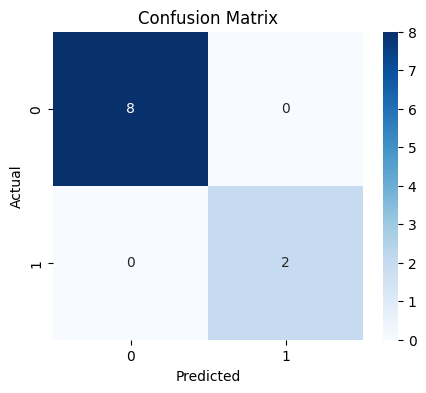

In [35]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



Analysis

Three classification models were trained and tested:
1. Logistic Regression
2. Decision Tree
3. Random Forest

The Random Forest model achieved the highest accuracy.
The confusion matrix shows most records were classified correctly.
Classification report indicates good precision, recall, and F1-score.
Therefore, Random Forest is selected as the best model.

Conclusion

This project implemented supervised learning classification using
Logistic Regression, Decision Tree, and Random Forest.

After evaluation using Accuracy Score, Confusion Matrix,
and Classification Report, Random Forest performed best.

The model can effectively predict project status based on
team size, budget, and duration.

In [37]:
from IPython.display import FileLink

FileLink("client_projects.csv")

/content/client_projects.csv

In [38]:
df.to_csv("client_projects.csv", index=False)

In [39]:
from IPython.display import FileLink
FileLink("client_projects.csv")

/content/client_projects.csv

In [40]:
from google.colab import files
files.download('client_projects.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>